In [1]:
from functions import *
import matplotlib.pyplot as plt
def get_QLF_v2(z, bin_num, dM, obscured, Mmid = 10., smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35], Lum = [5,16], Stell = [7,12]):

    qlf = QLF(z, bin_num, Lum, Stell)
    qlf.get_zparams()
    qlf.get_dNdMstar(smhm_scat)
    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL


In [2]:
%prun get_QLF_v2(2,100,.6,.7, Mmid=10.7,standev = [.85,.75,.3])


         6481 function calls (5476 primitive calls) in 0.032 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.006    0.006    0.008    0.008 necompiler.py:765(evaluate)
      101    0.004    0.000    0.004    0.000 functions.py:95(get_Mstar)
      100    0.002    0.000    0.003    0.000 functions.py:189(get_mean_etas)
        5    0.002    0.000    0.017    0.003 shape_base.py:270(apply_along_axis)
      100    0.002    0.000    0.002    0.000 functions.py:206(gauss)
        3    0.002    0.001    0.002    0.001 {built-in method scipy.interpolate._fitpack._spl_}
      100    0.001    0.000    0.001    0.000 functions.py:180(etas)
      100    0.001    0.000    0.001    0.000 functions.py:131(gauss_array)
        2    0.001    0.000    0.001    0.000 peaks.py:70(lagrangianR)
      639    0.001    0.000    0.001    0.000 {built-in method numpy.array}
        1    0.001    0.001    0.001    0.001 mass_function.py

Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

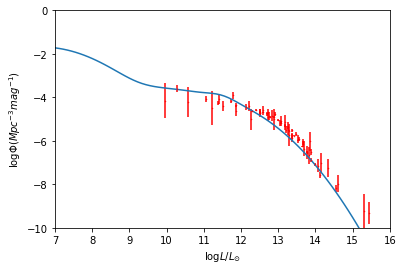

In [3]:
xi, yi = get_QLF_v2(2,100,.6,.7, Mmid=10.7,standev = [.85,.75,.3])
plt.plot(xi, yi)
z = 2
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')
